# RGB Image With Annotation Overlay

This notebook loads one RGB chip from the prepared SAM 3 dataset and visualizes the parcel polygons stored in the annotation JSON.


In [4]:
from pathlib import Path
import json

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from skimage.draw import polygon as draw_polygon


In [5]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_ROOT = PROJECT_ROOT / "data" / "processed" / "sam3_ftw"
ANNOTATION_PATH = DATASET_ROOT / "annotations" / "test.json"

with ANNOTATION_PATH.open("r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

print("Dataset root:", DATASET_ROOT)
print("Annotation file:", ANNOTATION_PATH)
print("Images:", len(images))
print("Annotations:", len(annotations))


Dataset root: /home/phuc/Python_Projects/LPBD/data/processed/sam3_ftw
Annotation file: /home/phuc/Python_Projects/LPBD/data/processed/sam3_ftw/annotations/test.json
Images: 3
Annotations: 476


In [6]:
IMAGE_INDEX = 0  # Change this to visualize a different image in the split.

image_info = images[IMAGE_INDEX]
image_path = DATASET_ROOT / image_info["file_name"]

image = Image.open(image_path).convert("RGB")
image_array = np.array(image)

image_annotations = [
    ann for ann in annotations
    if ann["image_id"] == image_info["id"]
]

print("Image:", image_path)
print("Image shape:", image_array.shape)
print("Image id:", image_info["id"])
print("Number of parcel annotations:", len(image_annotations))


Image: /home/phuc/Python_Projects/LPBD/data/processed/sam3_ftw/images/test/g0_0000002048-0000000000.png
Image shape: (256, 256, 3)
Image id: 1
Number of parcel annotations: 113


In [7]:
def segmentation_to_xy(segmentation):
    """Convert [x1, y1, x2, y2, ...] into an (N, 2) array."""
    points = np.asarray(segmentation, dtype=np.float32).reshape(-1, 2)
    return points


def build_mask_from_annotations(image_shape, anns):
    """Rasterize all polygon annotations into one binary mask."""
    height, width = image_shape[:2]
    mask = np.zeros((height, width), dtype=bool)

    for ann in anns:
        for segmentation in ann["segmentation"]:
            points = segmentation_to_xy(segmentation)
            xs = points[:, 0]
            ys = points[:, 1]
            rr, cc = draw_polygon(ys, xs, shape=mask.shape)
            mask[rr, cc] = True

    return mask


def build_polygon_patches(anns):
    """Create matplotlib polygon patches from COCO-style segmentations."""
    patches = []

    for ann in anns:
        for segmentation in ann["segmentation"]:
            points = segmentation_to_xy(segmentation)
            if len(points) >= 3:
                patches.append(Polygon(points, closed=True))

    return patches


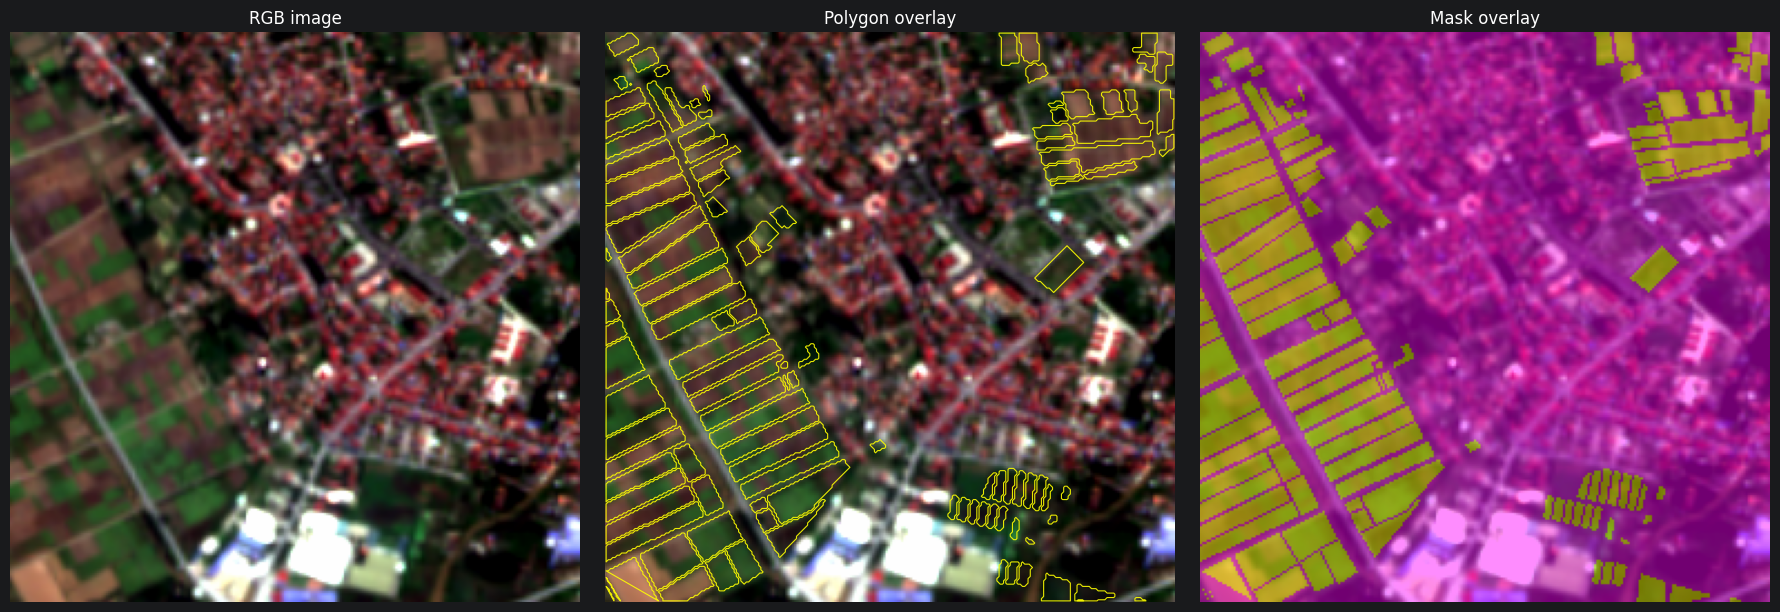

In [8]:
parcel_mask = build_mask_from_annotations(image_array.shape, image_annotations)
polygon_patches = build_polygon_patches(image_annotations)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_array)
axes[0].set_title("RGB image")
axes[0].axis("off")

axes[1].imshow(image_array)
if polygon_patches:
    collection = PatchCollection(
        polygon_patches,
        facecolor="none",
        edgecolor="yellow",
        linewidth=0.8,
        alpha=0.9,
    )
    axes[1].add_collection(collection)
axes[1].set_title("Polygon overlay")
axes[1].axis("off")

axes[2].imshow(image_array)
axes[2].imshow(parcel_mask, cmap="spring", alpha=0.45)
axes[2].set_title("Mask overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()
